In [187]:
import pandas as pd

data = pd.read_csv("../../data/raw/WESAD/S2/S2_E4_Data/TEMP.csv", header=None)


temp_raw = data[0].iloc[1:].astype(float).values 
temp_raw = temp_raw[5:]
temp_celsius = temp_raw
print(data)
print(temp_celsius[:10])
print("Mean:", temp_celsius.mean())
 

                  0
0      1.495437e+09
1      4.000000e+00
2      3.821800e+02
3      3.821800e+02
4      3.821800e+02
...             ...
31493  3.379000e+01
31494  3.381000e+01
31495  3.381000e+01
31496  3.381000e+01
31497  3.381000e+01

[31498 rows x 1 columns]
[35.05 35.05 35.05 35.05 35.07 35.07 35.07 35.07 35.09 35.09]
Mean: 34.56994665311825


In [188]:
import numpy as np
print("Mean:", np.mean(temp_celsius))
print("Min:", np.min(temp_celsius))
print("Max:", np.max(temp_celsius))

Mean: 34.56994665311825
Min: 32.31
Max: 35.97


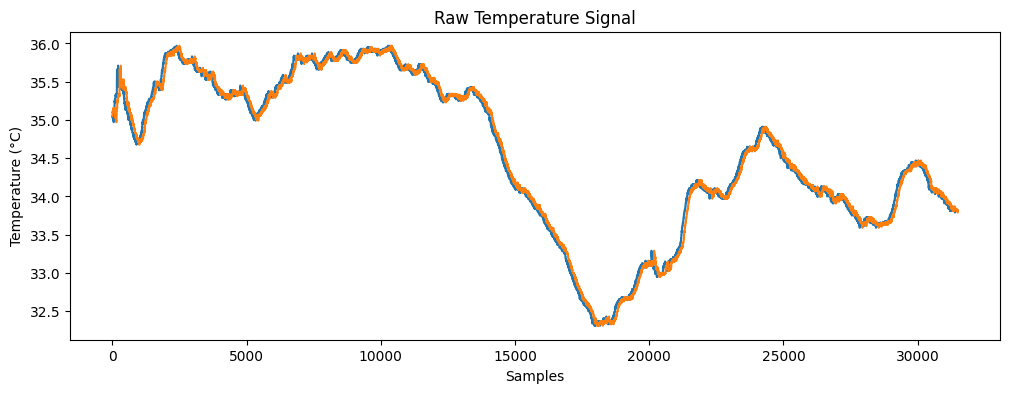

In [189]:
# VISUALIZATION
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(temp_celsius[100:])
plt.plot(temp_celsius)
plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")
plt.title("Raw Temperature Signal")
plt.show()

In [190]:
# low-Pass Filter

# Removes high-frequency noise.

from scipy.signal import butter, filtfilt

def lowpass_filter(signal, cutoff, fs, order=4):
    nyquist = fs / 2
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low')
    filtered_temp = filtfilt(b, a, signal)

    return filtered_temp

# Usage:

filtered_temp = lowpass_filter(temp_celsius,
                          cutoff=0.5,
                          fs=4)

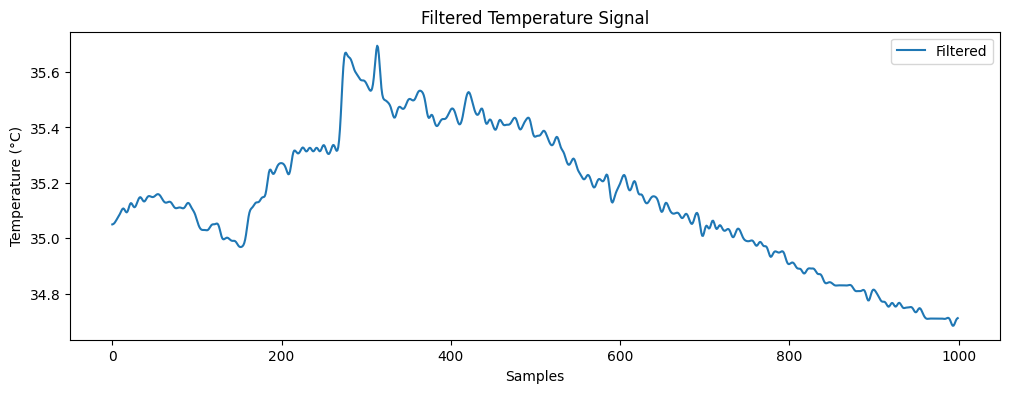

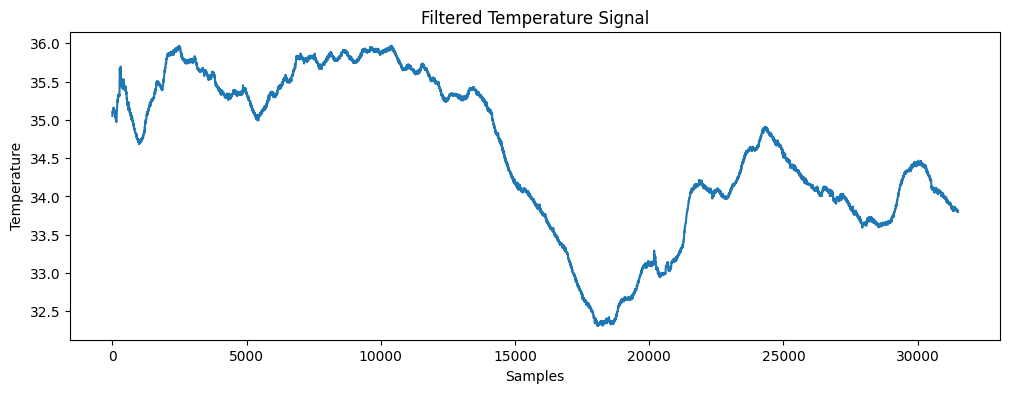

In [191]:
# VISUALIZATION
import matplotlib.pyplot as plt
start = 0
end = 1000
 
plt.figure(figsize=(12,4))

plt.plot(filtered_temp[start:end],
         label='Filtered')

plt.legend()
plt.xlabel("Samples")
plt.ylabel("Temperature (°C)")
plt.title("Filtered Temperature Signal")
plt.show()
plt.figure(figsize=(12,4))
plt.plot(filtered_temp)
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.title("Filtered Temperature Signal")
plt.show()

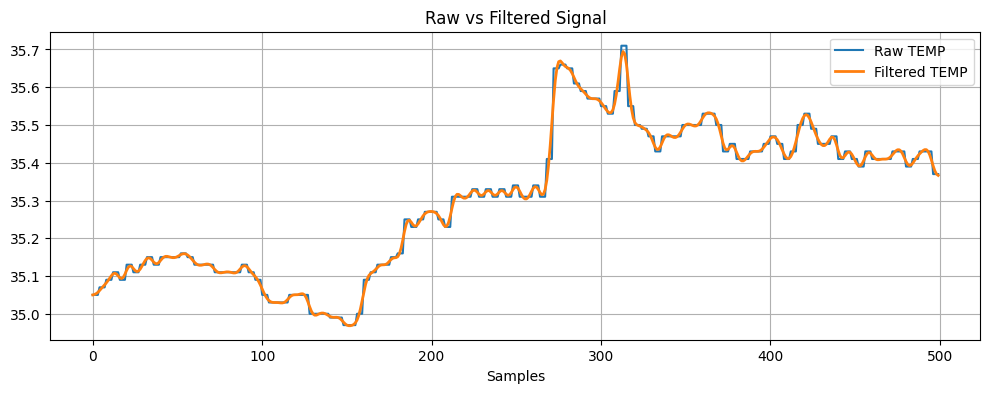

In [192]:
# Plot Comparison
# -------------------------
plt.figure(figsize=(12,4))

plt.plot(temp_celsius[:500], label='Raw TEMP')
plt.plot(filtered_temp[:500], label='Filtered TEMP', linewidth=2)

plt.title("Raw vs Filtered Signal")
plt.xlabel("Samples")
plt.ylabel("")

plt.legend()
plt.grid(True)

plt.show()

In [193]:
import numpy as np
from scipy.stats import linregress
import pandas as pd
 
# -------------------------
# Noise
# -------------------------
def calculate_noise(signal):
    return np.std(np.diff(signal))

# -------------------------
# Drift
# -------------------------
def calculate_drift(signal):
    x = np.arange(len(signal))
    slope, _, _, _, _ = linregress(x, signal)
    return slope

# -------------------------
# Generic Metrics
# -------------------------
def get_metrics(signal):
    return {
        "Samples": len(signal),
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Min": np.min(signal),
        "Max": np.max(signal),
        "Range": np.max(signal) - np.min(signal),
        "Noise": calculate_noise(signal),
      
        "Drift": calculate_drift(signal)
    }

# -------------------------
# Compare Raw vs Filtered
# -------------------------
def compare_signals(raw_signal, filtered_signal, signal_name="Signal"):

    raw_metrics = get_metrics(raw_signal)
    filtered_metrics = get_metrics(filtered_signal)

    print(f"\n========== {signal_name.upper()} ==========")

    for key in raw_metrics.keys():
        print(
            f"{key:<10} | Raw: {raw_metrics[key]:<12.6f} | Filtered: {filtered_metrics[key]:<12.6f}"
        )

    return raw_metrics, filtered_metrics

In [194]:
raw_metrics, filtered_metrics = compare_signals(
    temp_celsius,
    filtered_temp,
    "Temperature"
)

print("\n========== CHANGE ==========")

for key in raw_metrics.keys():

    raw = raw_metrics[key]
    filt = filtered_metrics[key]

    if raw != 0:
        change = ((filt - raw) / raw) * 100
        print(f"{key:<10}: {change:.2f}%")


========== TEMPERATURE ==========
Samples    | Raw: 31492.000000 | Filtered: 31492.000000
Mean       | Raw: 34.569947    | Filtered: 34.569947   
Std        | Raw: 1.014630     | Filtered: 1.014605    
Min        | Raw: 32.310000    | Filtered: 32.311745   
Max        | Raw: 35.970000    | Filtered: 35.967632   
Range      | Raw: 3.660000     | Filtered: 3.655887    
Noise      | Raw: 0.009895     | Filtered: 0.004522    
Drift      | Raw: -0.000073    | Filtered: -0.000073   

========== CHANGE ==========
Samples   : 0.00%
Mean      : -0.00%
Std       : -0.00%
Min       : 0.01%
Max       : -0.01%
Range     : -0.11%
Noise     : -54.30%
Drift     : 0.00%


In [196]:
filtered_temp = filtered_temp.copy()
filtered_temp[filtered_temp < 0] = 0
import numpy as np
from scipy.stats import linregress
import pandas as pd
 
# -------------------------
# Noise
# -------------------------
def calculate_noise(signal):
    return np.std(np.diff(signal))

# -------------------------
# Drift
# -------------------------
def calculate_drift(signal):
    x = np.arange(len(signal))
    slope, _, _, _, _ = linregress(x, signal)
    return slope

# -------------------------
# Generic Metrics
# -------------------------
def get_metrics(signal):
    return {
        "Samples": len(signal),
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Min": np.min(signal),
        "Max": np.max(signal),
        "Range": np.max(signal) - np.min(signal),
        "Noise": calculate_noise(signal),
      
        "Drift": calculate_drift(signal)
    }

# -------------------------
# Compare Raw vs Filtered
# -------------------------
def compare_signals(raw_signal, filtered_signal, signal_name="Signal"):

    raw_metrics = get_metrics(raw_signal)
    filtered_metrics = get_metrics(filtered_signal)

    print(f"\n========== {signal_name.upper()} ==========")

    for key in raw_metrics.keys():
        print(
            f"{key:<10} | Raw: {raw_metrics[key]:<12.6f} | Filtered: {filtered_metrics[key]:<12.6f}"
        )

    return raw_metrics, filtered_metrics
raw_metrics, filtered_metrics = compare_signals(
    temp_celsius,
    filtered_temp,
    "Temperature"
)

print("\n========== CHANGE ==========")

for key in raw_metrics.keys():

    raw = raw_metrics[key]
    filt = filtered_metrics[key]

    if raw != 0:
        change = ((filt - raw) / raw) * 100
        print(f"{key:<10}: {change:.2f}%")


========== TEMPERATURE ==========
Samples    | Raw: 31492.000000 | Filtered: 31492.000000
Mean       | Raw: 34.569947    | Filtered: 34.569947   
Std        | Raw: 1.014630     | Filtered: 1.014605    
Min        | Raw: 32.310000    | Filtered: 32.311745   
Max        | Raw: 35.970000    | Filtered: 35.967632   
Range      | Raw: 3.660000     | Filtered: 3.655887    
Noise      | Raw: 0.009895     | Filtered: 0.004522    
Drift      | Raw: -0.000073    | Filtered: -0.000073   

========== CHANGE ==========
Samples   : 0.00%
Mean      : -0.00%
Std       : -0.00%
Min       : 0.01%
Max       : -0.01%
Range     : -0.11%
Noise     : -54.30%
Drift     : 0.00%


| Metric                   | Interpretation                                  |
| ------------------------ | ----------------------------------------------- |
| Mean: 34.57 → 34.57      | ✅ Temperature level preserved                   |
| Std: 1.0146 → 1.0146     | ✅ Variability preserved                         |
| Min/Max almost unchanged | ✅ No distortion of signal amplitude             |
| Range: -0.11%            | ✅ Physiological temperature variations retained |
| Noise: -54.3%            | ✅ Excellent noise reduction                     |
| Drift: unchanged         | ✅ Long-term temperature trend preserved         |


What this tells you

Your filter:

Removed more than half of the high-frequency noise (54.3% reduction)
Did not change the actual temperature values
Did not flatten the signal
Did not alter the temperature trend

This is exactly what we want for TEMP.

Report Conclusion

The temperature filtering process successfully reduced signal noise by 54.3% while preserving the mean temperature, variability, range, and overall trend. The negligible changes in statistical characteristics (<0.1%) indicate that the physiological information contained in the signal was retained. Therefore, the filtered temperature signal is cleaner and more suitable for subsequent normalization and feature extraction.